In [9]:
import sys
from pathlib import Path

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)

Project root: /Users/ashutoshkhande/DM_Projects/misinfo_detection


In [10]:
import os
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc,
)

from src.utils import clean_text
from src.feature_engineering import build_tfidf_vectorizer

In [11]:
models_dir = project_root / "models"
results_dir = project_root / "results"
data_path = project_root / "data" / "processed" / "cleaned_dataset.csv"

models_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at: {data_path}")

df = pd.read_csv(data_path)

if "cleaned_text" not in df.columns:
    if "text" not in df.columns:
        raise ValueError("Dataset must contain either 'cleaned_text' or 'text'.")
    df["cleaned_text"] = df["text"].astype(str).apply(clean_text)

required_cols = {"text", "cleaned_text", "label"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print(df.shape)
df.head()

(60210, 6)


,text,is_rumor,user.handle,topic,label,cleaned_text
0,Charlie Hebdo became well known for publishing...,0.0,BBCDanielS,charliehebdo,0,charlie hebdo became well known publishing muh...
1,"Now 10 dead in a shooting there today RT ""@BBC...",0.0,robbylevy,charliehebdo,0,dead shooting today rt charlie hebdo became we...
2,@BBCDanielS @BBCWorld I'm guessing this is bei...,0.0,ModerateInAll,charliehebdo,0,im guessing considered terrorism right lone wolf
3,@BBCDanielS @BBCWorld why would you mention th...,0.0,GabTarquini,charliehebdo,0,would mention knowing fact
4,@BBCDanielS @BBCWorld perps identified?,0.0,freethought41,charliehebdo,0,perps identified


In [12]:
df[["text", "cleaned_text", "label"]].head()

,text,cleaned_text,label
0,Charlie Hebdo became well known for publishing...,charlie hebdo became well known publishing muh...,0
1,"Now 10 dead in a shooting there today RT ""@BBC...",dead shooting today rt charlie hebdo became we...,0
2,@BBCDanielS @BBCWorld I'm guessing this is bei...,im guessing considered terrorism right lone wolf,0
3,@BBCDanielS @BBCWorld why would you mention th...,would mention knowing fact,0
4,@BBCDanielS @BBCWorld perps identified?,perps identified,0


In [13]:
print("Class counts:")
print(df["label"].value_counts())

print("\nClass proportions:")
print(df["label"].value_counts(normalize=True))

Class counts:
label
0    46824
1    13386
Name: count, dtype: int64

Class proportions:
label
0    0.777678
1    0.222322
Name: proportion, dtype: float64


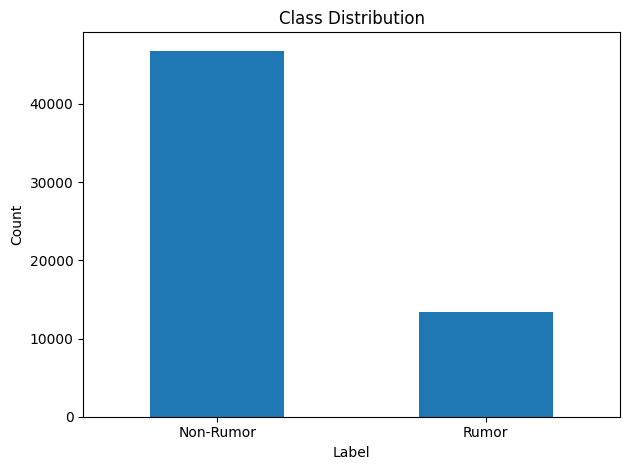

In [14]:
df["label"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Non-Rumor", "Rumor"], rotation=0)
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [15]:
X = df["cleaned_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (48168,)
Test shape: (12042,)

Train label distribution:
label
0    0.777674
1    0.222326
Name: proportion, dtype: float64

Test label distribution:
label
0    0.777695
1    0.222305
Name: proportion, dtype: float64


In [16]:
# ## Model Selection Setup

# This notebook compares multiple supervised learning classifiers for misinformation detection using TF-IDF text features.

# Models evaluated:
# - Logistic Regression
# - Multinomial Naive Bayes
# - Linear SVM

# The best model is selected using 5-fold cross-validated F1-score on the training set, and the selected model is then evaluated on the held-out test set.

In [17]:
model_configs = {
    "logistic_regression": {
        "pipeline": Pipeline([
            ("tfidf", build_tfidf_vectorizer()),
            ("clf", LogisticRegression(
                max_iter=3000,
                solver="liblinear",
                class_weight="balanced"
            )),
        ]),
        "params": {
            "tfidf__max_features": [3000, 5000, 7000],
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__min_df": [2, 3],
            "clf__C": [0.1, 1.0, 10.0],
        },
    },
    "naive_bayes": {
        "pipeline": Pipeline([
            ("tfidf", build_tfidf_vectorizer()),
            ("clf", MultinomialNB()),
        ]),
        "params": {
            "tfidf__max_features": [3000, 5000, 7000],
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__min_df": [2, 3],
            "clf__alpha": [0.1, 0.5, 1.0],
        },
    },
    "linear_svm": {
        "pipeline": Pipeline([
            ("tfidf", build_tfidf_vectorizer()),
            ("clf", LinearSVC(class_weight="balanced")),
        ]),
        "params": {
            "tfidf__max_features": [3000, 5000, 7000],
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__min_df": [2, 3],
            "clf__C": [0.1, 1.0, 10.0],
        },
    },
}

In [18]:
best_model = None
best_score = -1
best_name = None
best_params = None
all_results = []

for model_name, config in model_configs.items():
    print(f"\nRunning GridSearchCV for: {model_name}")

    grid_search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1,
        verbose=1,
    )

    grid_search.fit(X_train, y_train)

    result = {
        "model": model_name,
        "best_cv_f1": round(float(grid_search.best_score_), 4),
        "best_params": grid_search.best_params_,
    }
    all_results.append(result)

    print("Best params:", grid_search.best_params_)
    print("Best CV F1:", round(float(grid_search.best_score_), 4))

    if grid_search.best_score_ > best_score:
        best_score = grid_search.best_score_
        best_model = grid_search.best_estimator_
        best_name = model_name
        best_params = grid_search.best_params_


Running GridSearchCV for: logistic_regression
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'clf__C': 1.0, 'tfidf__max_features': 7000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
Best CV F1: 0.4808

Running GridSearchCV for: naive_bayes
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'clf__alpha': 0.1, 'tfidf__max_features': 7000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
Best CV F1: 0.3926

Running GridSearchCV for: linear_svm
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'clf__C': 0.1, 'tfidf__max_features': 7000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV F1: 0.4809


In [19]:
results_df = pd.DataFrame([
    {
        "model": r["model"],
        "best_cv_f1": r["best_cv_f1"],
        "best_params": str(r["best_params"])
    }
    for r in all_results
]).sort_values(by="best_cv_f1", ascending=False)

results_df

,model,best_cv_f1,best_params
2,linear_svm,0.4809,"{'clf__C': 0.1, 'tfidf__max_features': 7000, '..."
0,logistic_regression,0.4808,"{'clf__C': 1.0, 'tfidf__max_features': 7000, '..."
1,naive_bayes,0.3926,"{'clf__alpha': 0.1, 'tfidf__max_features': 700..."


In [20]:
print("Selected Best Model:", best_name)
print("Best Params:", best_params)
print("Best CV F1:", round(float(best_score), 4))

Selected Best Model: linear_svm
Best Params: {'clf__C': 0.1, 'tfidf__max_features': 7000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV F1: 0.4809


In [21]:
models_dir = project_root / "models"
results_dir = project_root / "results"

models_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

In [22]:
with open(models_dir / "best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

metadata = {
    "selected_model": best_name,
    "best_cv_f1": round(float(best_score), 4),
    "best_params": best_params,
    "all_model_results": all_results,
}

with open(models_dir / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("Saved best_model.pkl and model_metadata.json")

Saved best_model.pkl and model_metadata.json


In [23]:
y_pred = best_model.predict(X_test)

In [24]:
metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred)),
    "recall": float(recall_score(y_test, y_pred)),
    "f1_score": float(f1_score(y_test, y_pred)),
}

metrics

{'accuracy': 0.723716990533134,
 'precision': 0.4163233779608651,
 'recall': 0.6040343668285394,
 'f1_score': 0.4929126657521719}

In [25]:
clf = best_model.named_steps["clf"]

if hasattr(clf, "predict_proba"):
    y_scores = best_model.predict_proba(X_test)[:, 1]
elif hasattr(clf, "decision_function"):
    raw_scores = best_model.decision_function(X_test)
    raw_scores = np.asarray(raw_scores, dtype=float)

    if raw_scores.max() - raw_scores.min() == 0:
        y_scores = np.zeros_like(raw_scores)
    else:
        y_scores = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
else:
    y_scores = None

print("Scores available:", y_scores is not None)

Scores available: True


In [26]:
if y_scores is not None:
    metrics["roc_auc"] = float(roc_auc_score(y_test, y_scores))
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_scores)
    metrics["pr_auc"] = float(auc(recall_vals, precision_vals))

metrics

{'accuracy': 0.723716990533134,
 'precision': 0.4163233779608651,
 'recall': 0.6040343668285394,
 'f1_score': 0.4929126657521719,
 'roc_auc': 0.74499352914557,
 'pr_auc': 0.5217227586166947}

In [27]:
with open(results_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4)

print("Saved results/metrics.json")

Saved results/metrics.json


In [28]:
report = classification_report(y_test, y_pred, target_names=["Non-Rumor", "Rumor"])
print(report)

              precision    recall  f1-score   support

   Non-Rumor       0.87      0.76      0.81      9365
       Rumor       0.42      0.60      0.49      2677

    accuracy                           0.72     12042
   macro avg       0.64      0.68      0.65     12042
weighted avg       0.77      0.72      0.74     12042



In [29]:
with open(results_dir / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

print("Saved results/classification_report.txt")

Saved results/classification_report.txt


In [30]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[7098, 2267],
       [1060, 1617]])

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest")
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=[0, 1],
    yticks=[0, 1],
    xticklabels=["Non-Rumor", "Rumor"],
    yticklabels=["Non-Rumor", "Rumor"],
    xlabel="Predicted Label",
    ylabel="True Label",
    title=f"Confusion Matrix - {best_name}",
)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
        )

plt.tight_layout()
plt.show()

NameError: name 'y_test' is not defined

In [32]:
plt.tight_layout()
plt.savefig(results_dir / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.close()

with open(results_dir / "confusion_matrix_values.txt", "w", encoding="utf-8") as f:
    f.write(str(cm))

print("Saved results/confusion_matrix.png")
print("Saved results/confusion_matrix_values.txt")

Saved results/confusion_matrix.png
Saved results/confusion_matrix_values.txt


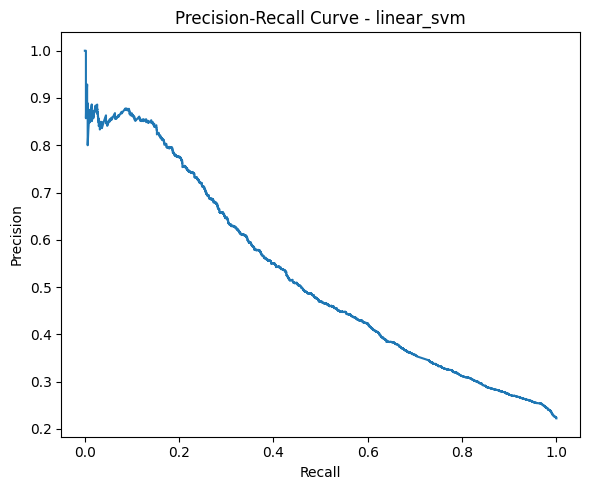

In [33]:
if y_scores is not None:
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_scores)
    plt.figure(figsize=(6, 5))
    plt.plot(recall_vals, precision_vals)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {best_name}")
    plt.tight_layout()
    plt.show()

In [34]:
tfidf = best_model.named_steps["tfidf"]
clf = best_model.named_steps["clf"]

if hasattr(clf, "coef_"):
    feature_names = np.array(tfidf.get_feature_names_out())
    coefficients = clf.coef_[0]

    top_non_rumor_idx = np.argsort(coefficients)[:20]
    top_rumor_idx = np.argsort(coefficients)[-20:][::-1]

    top_non_rumor = pd.DataFrame({
        "feature": feature_names[top_non_rumor_idx],
        "weight": coefficients[top_non_rumor_idx]
    })

    top_rumor = pd.DataFrame({
        "feature": feature_names[top_rumor_idx],
        "weight": coefficients[top_rumor_idx]
    })

    print("Top features indicating NON-RUMOR / TRUE")
    display(top_non_rumor)

    print("Top features indicating RUMOR / MISINFORMATION")
    display(top_rumor)
else:
    print(f"Top coefficient-based features are not available for {best_name}.")

Top features indicating NON-RUMOR / TRUE


,feature,weight
0,cartoon,-1.209181
1,explosion,-1.128169
2,protest,-1.031870
3,solidarity,-1.024005
4,mayor,-1.022873
5,blasphemy,-0.957977
6,silence,-0.949263
7,protester,-0.947629
8,group,-0.935099
9,satire,-0.931975


Top features indicating RUMOR / MISINFORMATION


,feature,weight
0,banksy,1.867113
1,robbery,1.712020
2,hostage,1.382869
3,banksys,1.207128
4,suspect,1.086518
5,smear,1.044386
6,cigar,1.030333
7,martyr,1.018204
8,invitation,0.961582
9,injured,0.954253


In [35]:
if hasattr(clf, "coef_"):
    feature_names = np.array(tfidf.get_feature_names_out())
    coefficients = clf.coef_[0]

    top_non_rumor_idx = np.argsort(coefficients)[:20]
    top_rumor_idx = np.argsort(coefficients)[-20:][::-1]

    with open(results_dir / "top_features.txt", "w", encoding="utf-8") as f:
        f.write("Top features indicating NON-RUMOR / TRUE class\n")
        f.write("=" * 50 + "\n")
        for idx in top_non_rumor_idx:
            f.write(f"{feature_names[idx]}: {coefficients[idx]:.4f}\n")

        f.write("\nTop features indicating RUMOR / MISINFORMATION class\n")
        f.write("=" * 50 + "\n")
        for idx in top_rumor_idx:
            f.write(f"{feature_names[idx]}: {coefficients[idx]:.4f}\n")

    print("Saved results/top_features.txt")
else:
    with open(results_dir / "top_features.txt", "w", encoding="utf-8") as f:
        f.write(f"Top coefficient-based features are not available for {best_name}.\n")
    print("Saved fallback results/top_features.txt")

Saved results/top_features.txt


In [36]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_pred,
})

misclassified = error_df[error_df["true_label"] != error_df["predicted_label"]].copy()
misclassified.head(20)

,text,true_label,predicted_label
1,police still haven’t found killer here’s latest,0,1
2,shocked appaled nothing justify attack,0,1
4,cop still trying run,0,1
6,officer think he dealing guy wont get middle s...,0,1
8,armed men reportedly asking journalist name ch...,1,0
9,wouldnt trust pd telling weather report,0,1
11,need people like tarek fatah he never equivoca...,0,1
16,couldnt reverse said,0,1
18,bad dont know,0,1
22,cop body cam dash cam interior car cam,0,1


In [37]:
misclassified.to_csv(results_dir / "misclassified_examples.csv", index=False)
print("Saved results/misclassified_examples.csv")

Saved results/misclassified_examples.csv


In [38]:
sample_text = "Reports say a miracle cure was discovered overnight with no proof."
cleaned = clean_text(sample_text)

pred = int(best_model.predict([cleaned])[0])
clf = best_model.named_steps["clf"]

if hasattr(clf, "predict_proba"):
    probs = best_model.predict_proba([cleaned])[0]
    non_rumor_score = float(probs[0])
    rumor_score = float(probs[1])
elif hasattr(clf, "decision_function"):
    raw_score = float(best_model.decision_function([cleaned])[0])
    rumor_score = 1 / (1 + np.exp(-raw_score))
    non_rumor_score = 1 - rumor_score
else:
    non_rumor_score = None
    rumor_score = None

predicted_label = "RUMOR / MISINFORMATION" if pred == 1 else "NON-RUMOR / TRUE"

result = {
    "selected_model": best_name,
    "original_text": sample_text,
    "cleaned_text": cleaned,
    "predicted_numeric_label": pred,
    "predicted_label": predicted_label,
    "non_rumor_score": round(non_rumor_score, 4) if non_rumor_score is not None else None,
    "rumor_score": round(rumor_score, 4) if rumor_score is not None else None,
}

result

{'selected_model': 'linear_svm',
 'original_text': 'Reports say a miracle cure was discovered overnight with no proof.',
 'cleaned_text': 'reports say a miracle cure was discovered overnight with no proof',
 'predicted_numeric_label': 1,
 'predicted_label': 'RUMOR / MISINFORMATION',
 'non_rumor_score': np.float64(0.4562),
 'rumor_score': np.float64(0.5438)}

In [39]:
print("Final selected model:", best_name)
print("Best CV F1:", round(float(best_score), 4))
print("Test metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Final selected model: linear_svm
Best CV F1: 0.4809
Test metrics:
accuracy: 0.7237
precision: 0.4163
recall: 0.6040
f1_score: 0.4929
roc_auc: 0.7450
pr_auc: 0.5217


In [40]:
# ## Final Conclusion

# Multiple supervised learning models were compared using TF-IDF text features and 5-fold cross-validated F1-score.  
# The best-performing model was selected and evaluated on a held-out test set using accuracy, precision, recall, F1-score, confusion matrix, and additional ranking-based metrics where applicable.  
# This provides a stronger and more rigorous misinformation-detection pipeline than using a single classifier alone.